In [16]:
# 결정 트리로 와인 품종 분류하기

from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['class'] = wine.target
print(wine.target_names)
df.head()

['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [17]:
# 학습 데이터 준비

from sklearn.model_selection import train_test_split

X_data = df.iloc[:, :-1]
# X_data에는 마지막 열을 제외한 모든 열이 들어감. 즉, 와인 데이터의 특성(feature)들이 X_data에 저장됨.

# alcohol  malic_acid  ash  ...  proline │  class
#   14.23      1.71   2.43  ...  1065.0  │    0
#   13.20      1.78   2.14  ...  1050.0  │    0
#   ...                                  │   ...
# └──────── 특성 13개 (문제) ─────────────┘ └정답┘

# 마지막 열이 정답열이기 때문에 X_data에선 제외.

y_data = df.iloc[:, -1]
# y_data에는 마지막 열 하나만 들어감. 즉, 와인 데이터의 정답(label)들이 y_data에 저장됨.

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state= 156)
# train_test_split() 함수는 데이터를 학습용과 테스트용으로 나누는 함수. 
# test_size=0.2는 전체 데이터 중 20%를 테스트용으로 사용하겠다는 의미. 
# random_state=156은 난수 발생 시드값을 지정하여, 동일한 시드값을 사용하면 항상 같은 결과를 얻을 수 있도록 함.

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(142, 13) (36, 13)
(142,) (36,)


In [ ]:
# 학습 / 예측 / 평가

from sklearn.tree import DecisionTreeClassifier     # 결정 트리 알고리즘을 사용하기 위해 DecisionTreeClassifier 임포트
from sklearn.metrics import accuracy_score          # 정확도 평가를 위해 accuracy_score 임포트

# [1] 모델 만들기
dt_clf = DecisionTreeClassifier(random_state = 156)
    # - DecisionTreeClassifier 객체 생성.
    # - random_state는 난수 고정값 지정.
    #    - 트리가 가지를 나눌 때 동점 상황에서 어느쪽을 고를지가 랜덤하게 결정되는데,
    #      random_state 값을 지정하면 몇 번을 돌려도 항상 같은 결과를 얻을 수 있어 결과 재현이 가능.

# [2] 학습
dt_clf.fit(X_train, y_train)
    # - fit() 메서드를 이용해 학습 데이터를 학습시킴.
    # - 문제(X_train)와 정답(y_train)을 같이 보여주며 규칙을 찾게 함.
    # - ★ 학습에는 train 데이터만 사용하고, test 데이터는 학습에 사용하지 않음.
    # - 시험 문제를 미리 보여주는 셈이라 평가 점수가 의미 없어짐 (데이터 누수)

# [3] 예측
pred = dt_clf.predict(X_test)
    # - predict() 메서드를 이용해 학습된 모델에 테스트 데이터를 넣어 예측값을 반환받음.
    # - 학습된 트리에 문제만 주고 답을 맞춰보게 하는 것과 같음. (정답은 알려주지 않음)
    # - 결과는 클래스 번호 배열로 출력 → ex) [0 2 1 1 0 ...]  shape (36,)

# [4] 예측 확률
pred_proba = dt_clf.predict_proba(X_test)   # ROC-AUC 스코어를 찍기 위해 사용
    # - predict_proba() 메서드를 이용해 학습된 모델에 테스트 데이터를 넣어 예측 확률을 반환받음.
    # - 정답 하나가 아니라 "각 클래스일 확률"을 반환함. (정답일 확률이 가장 높은 클래스를 예측값으로 반환)
    # - 결과는 클래스별 확률 배열로 출력 → ex) [[0.9 0.1 0. ] [0. 0. 1. ] ...]  shape (36, 3)
    # - shape (36, 3) → 행 하나가 와인 한 병, 열 3개가 class 0 / 1 / 2 확률
    # - 한 행의 합은 항상 1이 됨. (0~1 사이의 확률이므로)
    #   ex) [0.0, 0.9, 0.1] → class 1 이라고 90% 확신
    # - ROC-AUC 처럼 확률이 필요한 지표를 계산할 때 사용 (정확도는 필요 없음)
    #                                                  (이 노트북에선 계산 안함)

# [5] 평가
accuracy = accuracy_score(y_test, pred)
    # - accuracy_score() 메서드를 이용해 예측값과 실제값을 비교하여 정확도를 계산함.
    # - ★ 인자 순서(정답, 예측값)를 바꿔 넣어도 정확도는 같지만,
    #   정밀도와 재현율에서는 값이 달라지므로 순서를 습관으로 굳혀두는 것을 추천

print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.9444


In [19]:
dt_clf

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",156
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [ ]:
# GridSearchCV를 이용한 하이퍼 파라미터 튜닝
# - GridSearchCV는 교차 검증을 통해 최적의 하이퍼 파라미터를 찾는 방법으로, 
#   여러 하이퍼 파라미터 조합을 시도하여 가장 좋은 성능을 내는 모델을 선택함.
# - 하이퍼 파라미터 = 모델 학습 전에 사람이 직접 설정하는 값으로, 학습으로 저절로 정해지는 값이 아니다.
# - Grid(격자)는 하이퍼 파라미터 후보들을 격자 형태로 나열하여 모든 조합을 시도한다는 의미.
from sklearn.model_selection import GridSearchCV

# [1] 시험해 볼 후보값들을 딕셔너리로 작성
parameters = {'criterion':['gini', 'entropy'],
              'max_depth':[None, 2, 3, 5, 7],
              'min_samples_split':[2, 3, 5, 7],
              'min_samples_leaf':[1, 3, 5, 7]
              }
    # - {'파라미터 이름' : [후보값 리스트]} 형태
    # - 이때 키 이름은 모델이 실제로 받는 파라미터 이름과 정확히 같아야 함.

    #   - criterion: 불순도 계산(측정) 방식을 선택하는 파라미터
    #   - gini(지니 계수) : 계산이 빠르고 해석이 쉬움(기본값)
    #   - entropy : 정보 이득(Information Gain) 기반 계산 방식.
    #               보통 결과는 gini와 비슷하지만, 데이터에 따라 성능이 더 좋을 수도 있음.

    #   - max_depth: 트리의 최대 깊이. 깊이가 깊어질수록 모델이 복잡해지고 과적합(overfitting) 위험이 커짐.
    #     - None: 제한 없어 트리가 끝까지 성장. (과적합 위험 ↑)
    #     - 숫자 지정: 트리의 최대 깊이를 제한. (과적합 위험 ↓)

    #   - min_samples_split: 노드를 분할하기 위한 최소 샘플 수. (기본 2, 과적합 방지)
    #     - 값을 키웠을 때 "샘플이 적은 노드는 분할하지 않고 그대로 두게 됨" → 트리 단순해짐, 과적합 방지

    #   - min_samples_leaf: 리프 노드(마지막 노드)가 되기 위한 최소 샘플 수. (기본 1, 과적합 방지)
    #     - 값이 3이면 모든 잎이 샘플을 최소 3개 이상 갖게 된다.

    # - 조합 개수 = 2 * 5 * 4 * 4 = 160가지

# [2] 탐색기 만들기
grid_dt = GridSearchCV(dt_clf, param_grid = parameters, cv = 5)
    # dt_clf: 튜닝할 모델. 원본은 건드리지 않고 복제해서 사용함
    #         앞의 셀에서 준 random_state=156은 그대로 유지됨

    # param_grid: [1]에서 만든 후보 딕셔너리

    # cv = 5: 5겹 교차 검증
    #         X_train을 5등분 → 4조각은 학습, 1조각으로 검증함
    #         → 검증 조각을 바꿔가며 5번 반복 → 점수 5개의 평균을 사용함
    #         - 한 번만 나눠 평가하면 운에 좌우되므로 5번 평균이 안정적이다.

    # GridSearchCV에 Scoring 옵션을 안넣었으므로 → 분류 모델은 디폴트로 "정확도" 기준으로 채점
    # scoring='f1'이면 F1점수로 채점, 
    # scoring='roc_auc'이면 AUC로 채점

# [3] 탐색 실행
grid_dt.fit(X_train, y_train)
    # - 160가지 조합 * 5겹 = 총 800번 학습
    # - ★ 여기서도 X_train만 사용. X_test는 끝까지 아껴둠.
    #      (검증용 데이터는 train 안에서 만들어 쓰는것)
    #   - 즉 하이퍼 파라미터를 고를 때 쓰는 검증 데이터는 따로 떼어둔 게 아니라, 
    #     GridSearchCV가 X_train을 쪼개서 그때그때 만든다는 의미임.
    # - test: 최종 모델을 딱 한번 평가. 처음 보는 데이터에서 성능이 얼마나 나오는지 확인하는 용도.


scores_df = pd.DataFrame(grid_dt.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score']]

,params,mean_test_score,rank_test_score
0,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.851478,101
1,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.851478,101
2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.858621,68
3,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.865517,65
4,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.858621,68
...,...,...,...
155,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.858621,68
156,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.865764,33
157,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.865764,33
158,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.865764,33


In [21]:
# [4] 탐색 결과 확인
print('GridSearchCV 최적 파라미터:', grid_dt.best_params_)
    # - best_params_: 160가지 조합 중 5-fold 평균 점수가 가장 높았던 조합(딕셔너리 형태)
    #   ex) {'max_depth': 5, 'min_samples_split': 10}

print(f'GridSearchCV 최고 정확도: {grid_dt.best_score_:.4f}')
    # - best_score_: 그 최적 조합의 "5-fold 검증 점수 평균"
    #   (GridSearchCV에 Scoring 옵션을 안넣었음 → 분류 모델은 디폴트로 "정확도" 기준으로 채점

GridSearchCV 최적 파라미터: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
GridSearchCV 최고 정확도: 0.8936


In [ ]:
model = grid_dt.best_estimator_
    # - best_estimator_: 최적 파라미터로 X_train 전체를 다시 학습한 모델(refit=True가 기본값)
    #   → 교차검증 때는 train의  4/5로만 학습했지만, 이건 train 전체로 학습한 최종 모델

# [5] 최종 평가
pred = model.predict(X_test)
    # - 이제 처음으로 X_test 사용함
    # - model = best_estimator_ : 최적 파라미터로 X_train 전체를 다시 학습한 최종 모델
    # - X_test의 정답(y_test)은 주지 않고 문제(X_test)만 줘서 예측값을 뽑음
    # - pred: 예측한 클래스 배열 ex) [0, 1, 1, 0, ...]

accuracy_score(y_test, pred)
    # - 실제 정답(y_test)과 예측값(pred)을 비교해서 맞힌 비율 = 정확도
    #   ex) 100개 중 85개 맞힘 → 0.85
    # - 이것이 모델의 진짜 성능을 의미함.
    #   학습에도, 파라미터 고르는 데도 안 쓰인 데이터로 채점했기 때문

    # - 앞의 best_score_ (train 안에서 교차검증한 점수)와 비교해보면
    #   - 비슷함 → 새 데이터에서도 성능이 잘 유지됨(일반화 잘 됨)
    #   - test가 훨씬 더 낮음 → 과적합 의심
    # - 인자 순서: accuracy_score(정답, 예측)
    #   - 정확도는 인자 순서를 바꿔도 같지만, precision/recall 같은 지표는 순서가 바뀌면 값이 달라짐
    

1.0

In [23]:
# [6] 클래스별 상세 성능 리포트
from sklearn.metrics import classification_report
print(classification_report(y_test, pred, target_names=wine.target_names))

# - accuracy_score는 전체 몇% 맞췄는지 숫자로 나옴
#   → classification_report는 클래스(와인 종류)별로 쪼개서 보여줌
# - target_names: 0, 1, 2 대신 'class_0', 'class_1', 'class_2' 같이 이름으로 보여줌

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        11
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        11

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



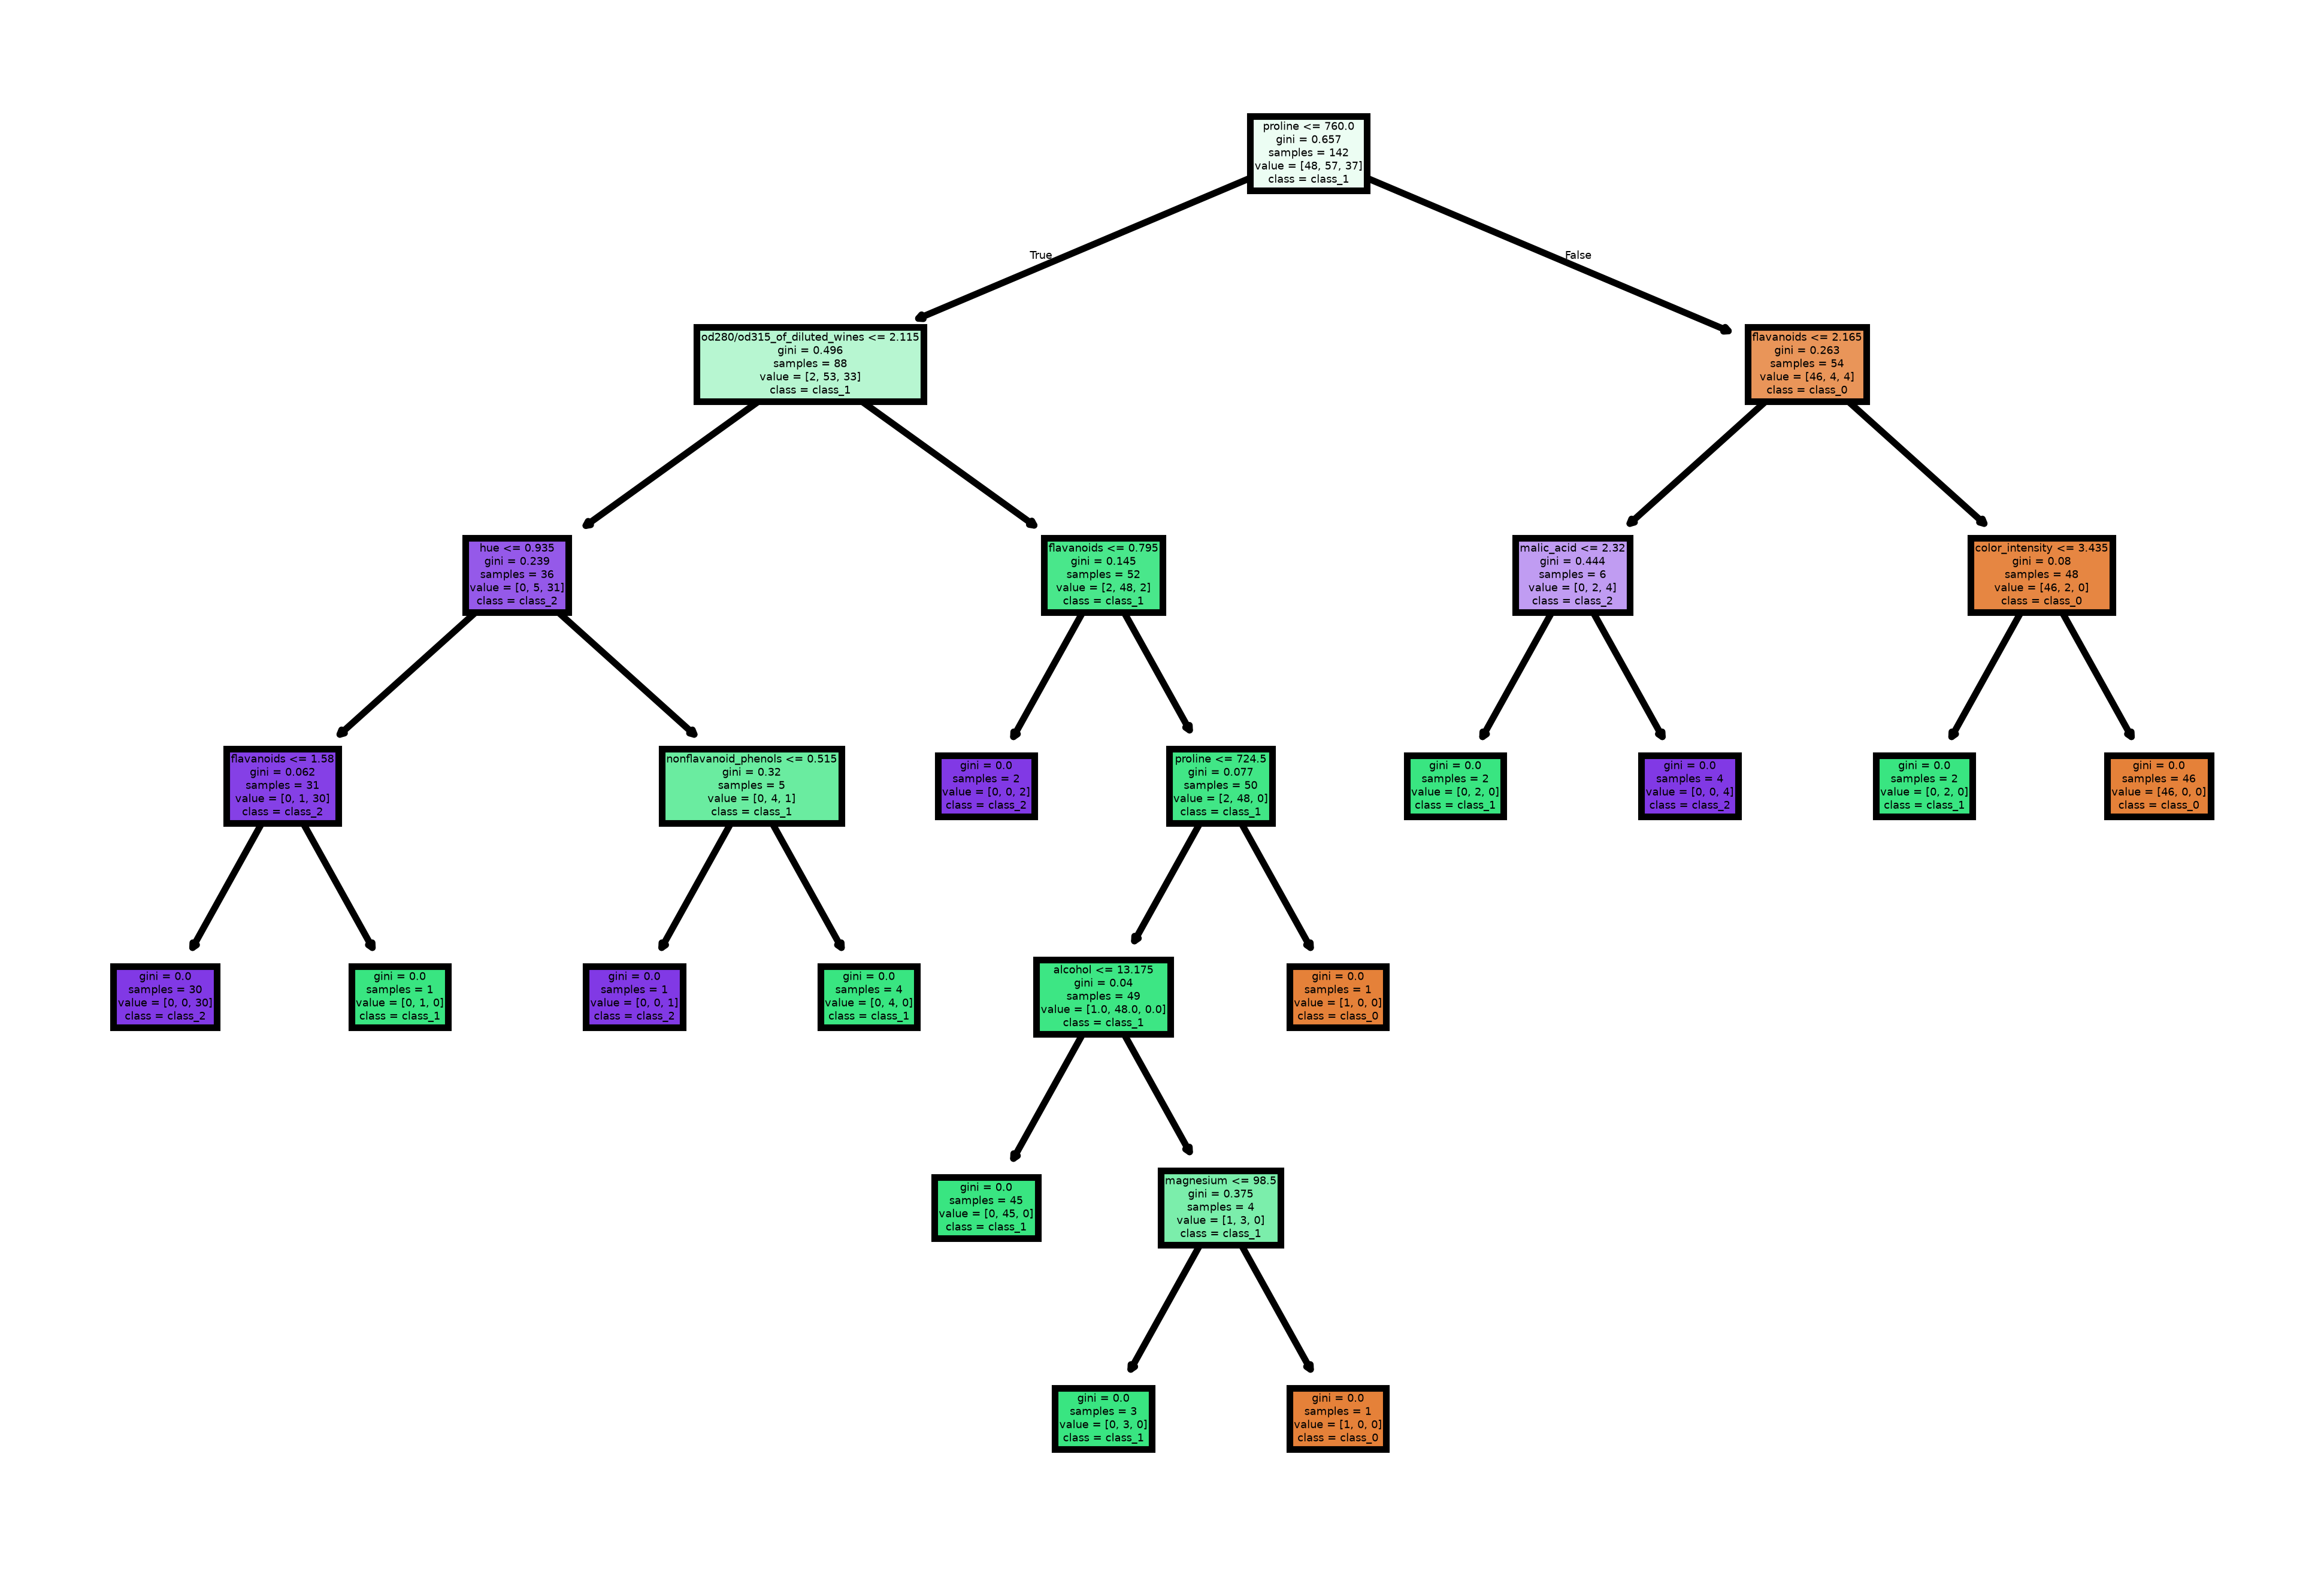

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(6, 4), dpi = 800)
plot_tree(dt_clf, filled=True, feature_names=wine.feature_names, class_names=list(wine.target_names))
plt.show()

In [ ]:
# 피쳐 중요도
dt_clf.feature_importances_
    # - 트리가 와인을 분류할 때 각 피쳐(열)을 얼마나 쓸모있게 썼는지 나타낸 점수
    # - 결과: 피쳐 13개 만큼의 숫자 배열.
    # - 모든 값을 더하면 1

# [해석 주의]
# - 0은 이 트리에서 안썼다는 뜻이지 쓸모없다는 뜻은 아님
#   (다른 feature와 정보가 겹쳐서 밀렸을 수도 있음)

array([0.00492404, 0.02859588, 0.        , 0.        , 0.01608518,
       0.        , 0.14322427, 0.01715753, 0.        , 0.04110658,
       0.05442826, 0.2949971 , 0.39948115])

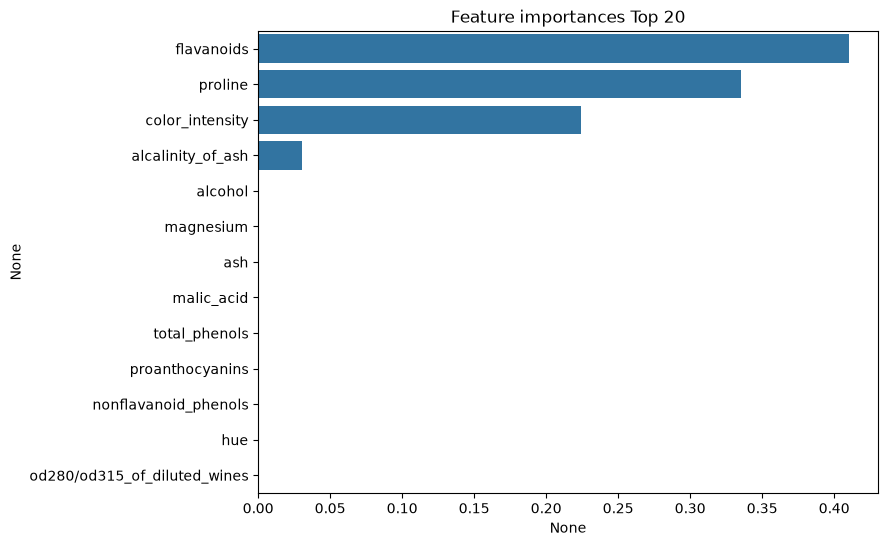

In [26]:
# 피쳐 중요도 그래프
import seaborn as sns
import matplotlib.pyplot as plt

ftr_importances_values = model.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8, 6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y = ftr_top20.index)
plt.show()